In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

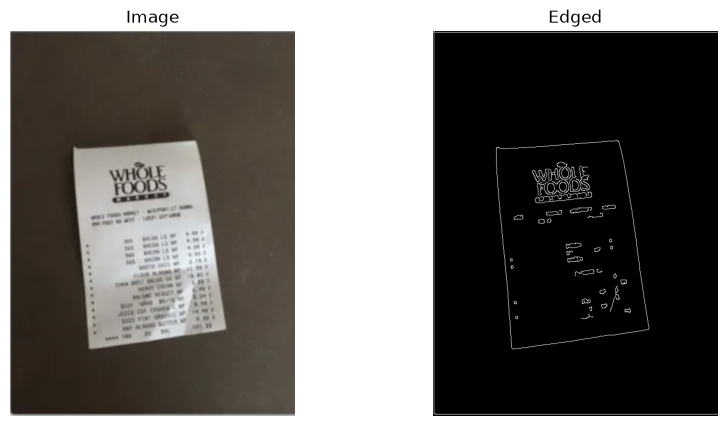

In [6]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("fiş.jpg")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)
# Görüntüdeki küçük pürüz ve gürültüleri temizlemek için 5x5 Gauss Bulanıklaştırma filtresi uygular.

edged = cv2.Canny(blurred, 75, 200)
# Canny algoritması ile belgenin ve üzerindeki detayların keskin kenarlarını tespit eder.

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Orijinal resmi Matplotlib'de doğru renklerle göstermek için BGR -> RGB çevirisi yapar.

plt.figure(figsize=(10, 5))
# Yan yana gösterim için 10x5 boyutlarında bir görsel penceresi oluşturur.

plt.subplot(1, 2, 1)
# Yan yana düzenin 1. sırasına orijinal resmi koyar.

plt.imshow(image_rgb)

plt.title("Image")

plt.axis("off")

plt.subplot(1, 2, 2)
# Yan yana düzenin 2. sırasına kenar haritasını koyar.

plt.imshow(edged, cmap="gray")
# Canny kenar haritasını (Edged) siyah-beyaz olarak hazırlar.

plt.title("Edged")

plt.axis("off")

plt.show()



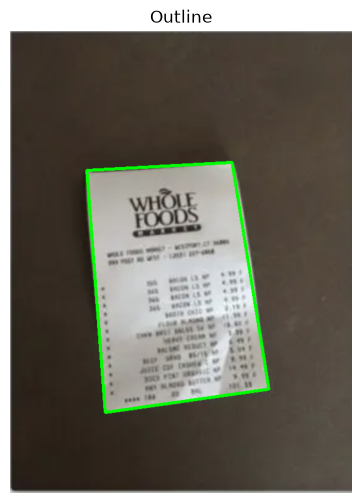

In [4]:
cnts, _ = cv2.findContours(
    edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE
)

cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:5]
# Bulunan konturları alanlarına göre büyükten küçüğe sıralar ve en büyük 5 tanesini seçer.

screenCnt = None
# Belgenin 4 köşeli sınırlarını saklamak için boş bir değişken tanımlar.

for c in cnts:
    # Seçilen en büyük 5 kontur üzerinde sırayla döngü başlatır.

    peri = cv2.arcLength(c, True)
    # Konturun çevre uzunluğunu hesaplar.

    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    # Kontur çizgilerini yumuşatarak köşe noktalarının sayısını (poligon yaklaşımını) hesaplar.

    if len(approx) == 4:
        # Eğer köşe sayısı tam 4 ise (yani dikdörtgen/dörtgen şeklinde belgenin kendisiyse):
        screenCnt = approx
        # Belge konturunu saklar ve döngüden çıkar.
        break

output = image_rgb.copy()
# Orijinal renkli resmin kopyasını oluşturur.

cv2.drawContours(output, [screenCnt], -1, (0, 255, 0), 3)
# Bulunan 4 köşeli belge sınırının etrafına yeşil renkli ((0, 255, 0) RGB), 3 piksel kalınlığında kontur çizer.

plt.figure(figsize=(6, 6))
# Görsel penceresinin boyutunu 6x6 olarak ayarlar.

plt.imshow(output)
# Yeşil çizgiyle çevrelenmiş belge resmi ekranda gösterilmek üzere hazırlar.

plt.title("Outline")

plt.axis("off")

plt.show()



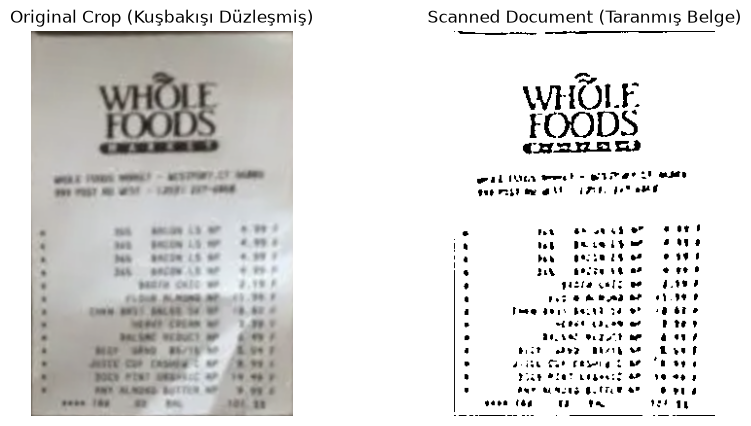

In [11]:
import numpy as np

# 1. Belgenin 4 Köşe Noktasını Sıralama (Sol-Üst, Sağ-Üst, Sağ-Alt, Sol-Alt)
pts = screenCnt.reshape(4, 2)
rect = np.zeros((4, 2), dtype="float32")

s = pts.sum(axis=1)
rect[0] = pts[np.argmin(s)]  # Sol-üst köşe
rect[2] = pts[np.argmax(s)]  # Sağ-alt köşe

diff = np.diff(pts, axis=1)
rect[1] = pts[np.argmin(diff)]  # Sağ-üst köşe
rect[3] = pts[np.argmax(diff)]  # Sol-alt köşe

(tl, tr, br, bl) = rect

# 2. Düzleştirilecek Yeni Belgenin Genişlik ve Yükseklik Boyutlarını Hesaplama
widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
maxWidth = max(int(widthA), int(widthB))

heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
maxHeight = max(int(heightA), int(heightB))

# 3. Düzleştirilmiş Hedef Kuşbakışı Ekran Koordinatları
dst = np.array(
    [
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1],
    ],
    dtype="float32",
)

# 4. Perspektif Dönüşüm Matrisini Hesaplama ve Resmi Düzleştirme (Warp)
M = cv2.getPerspectiveTransform(rect, dst)
warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
# Eğik duran belgeyi tam karşıdan dik açıyla çekilmiş gibi düzleştirip kırpar.

# 5. Gerçek Belge Tarayıcı (CamScanner) Etkisi İçin Siyah-Beyaz Netleştirme
warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
scanned = cv2.adaptiveThreshold(
    warped_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 10
)
# Kağıdı temiz beyaz, üzerindeki tüm yazıları net siyah yapar.

warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

# 6. Sonuçları Ekranda Yan Yana Gösterme
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(warped_rgb)
plt.title("Original Crop (Kuşbakışı Düzleşmiş)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(scanned, cmap="gray")
plt.title("Scanned Document (Taranmış Belge)")
plt.axis("off")

plt.show()

